In [41]:
# %pip install geopandas
%pip install scikit-learn
%pip install pointpats


import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import math

from shapely.geometry import Point, Polygon
from sklearn.neighbors import KernelDensity
from pointpats import PointPattern, k, k_test
from scipy.spatial.distance import pdist


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
df = pd.read_csv("postal_code_floods.csv")

# Flood events to GeoDataFrame (EPSG:4326 → EPSG:3414)
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
).to_crs("EPSG:3414")

# Load planning area polygons
planning_area = gpd.read_file("../roadnetwork/geojson/planning_area.geojson").to_crs("EPSG:3414")

# Define unified study region (owin equivalent)
study_area = planning_area.unary_union

print(f"Loaded {len(gdf)} flood events across {len(planning_area)} planning areas")


Loaded 214 flood events across 55 planning areas


/var/folders/dm/z_zvyzrd1sn7_mdfpl26_bvh0000gn/T/ipykernel_23961/1810225306.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_area = planning_area.unary_union


In [23]:
coords = np.array(list(zip(gdf.geometry.x, gdf.geometry.y)))
pp = PointPattern(coords)

# Nearest neighbour distances
nn_dists, nn_idx = pp.knn(k=1)
avg_nn = nn_dists.mean()

# Expected NN distance under CSR
area = study_area.area
lambda_density = len(coords) / area
expected_nn = 1 / (2 * np.sqrt(lambda_density))

R = avg_nn / expected_nn

print(f"Observed NN distance: {avg_nn:.2f} m")
print(f"Expected NN distance (CSR): {expected_nn:.2f} m")
print(f"Clark–Evans R: {R:.3f}")

Observed NN distance: 107.92 m
Expected NN distance (CSR): 957.58 m
Clark–Evans R: 0.113


In [24]:
coords = np.vstack([gdf.geometry.x, gdf.geometry.y]).T

# Evaluation grid
xmin, ymin, xmax, ymax = planning_area.total_bounds
xx, yy = np.meshgrid(
    np.linspace(xmin, xmax, 300),
    np.linspace(ymin, ymax, 300)
)
grid_coords = np.vstack([xx.ravel(), yy.ravel()]).T

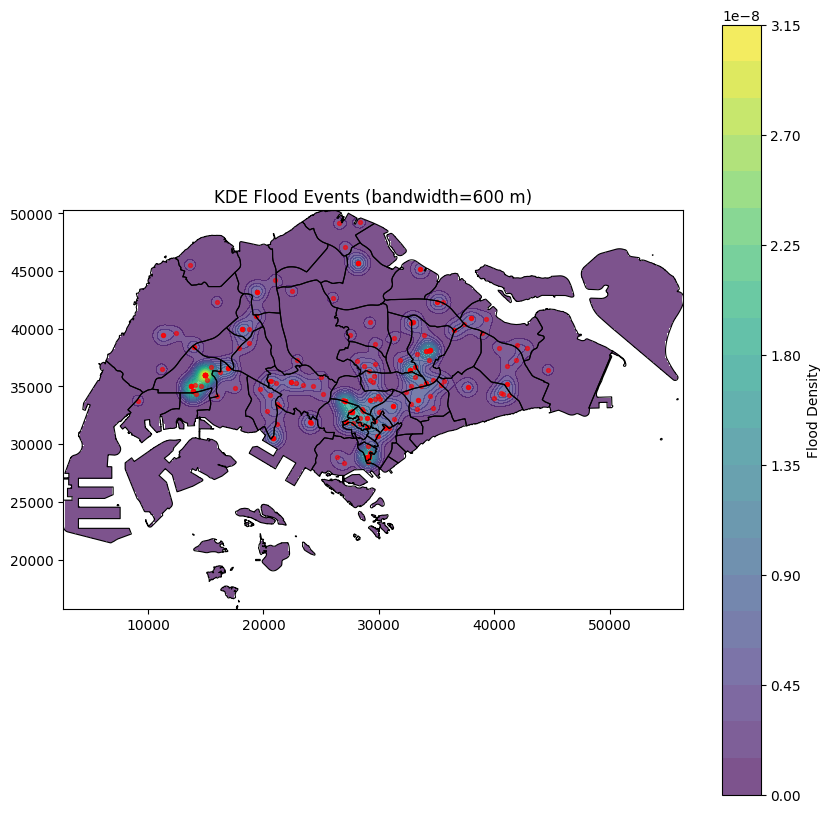

In [25]:
bandwidth = 600
kde = KernelDensity(bandwidth=bandwidth, kernel="gaussian").fit(coords)

zz = np.exp(kde.score_samples(grid_coords)).reshape(xx.shape)

# Mask outside planning area
mask = np.array([study_area.contains(Point(x, y)) for x, y in grid_coords]).reshape(xx.shape)
zz_masked = np.where(mask, zz, np.nan)

fig, ax = plt.subplots(figsize=(10,10))
planning_area.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8)
c = ax.contourf(xx, yy, zz_masked, cmap="viridis", levels=20, alpha=0.7)
gdf.plot(ax=ax, color="red", markersize=8, alpha=0.6)
fig.colorbar(c, ax=ax, label="Flood Density")
plt.title(f"KDE Flood Events (bandwidth={bandwidth} m)")
plt.show()

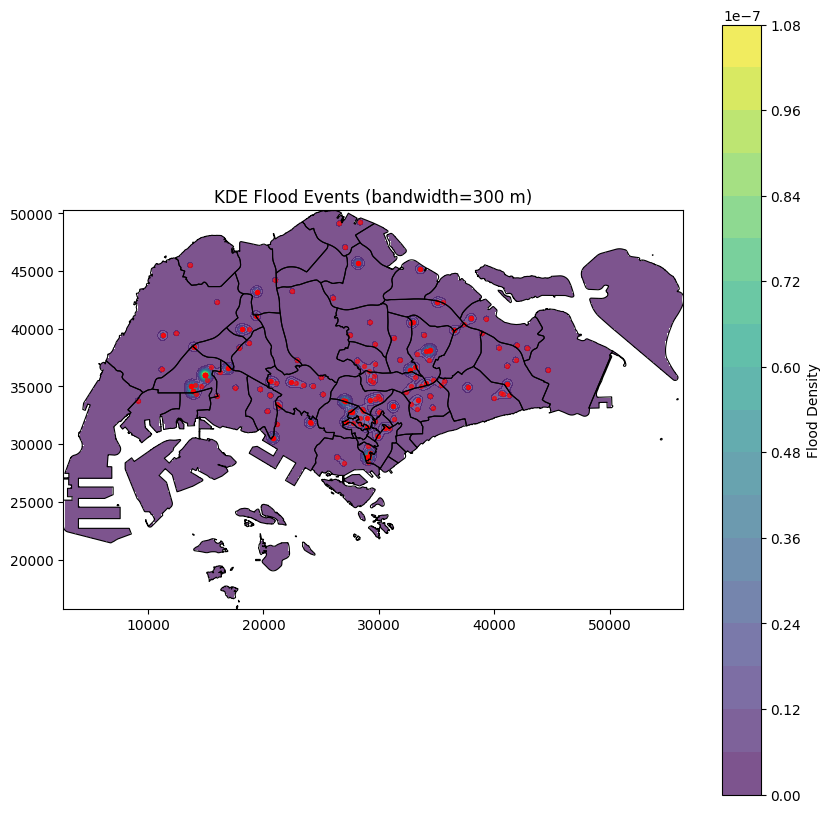

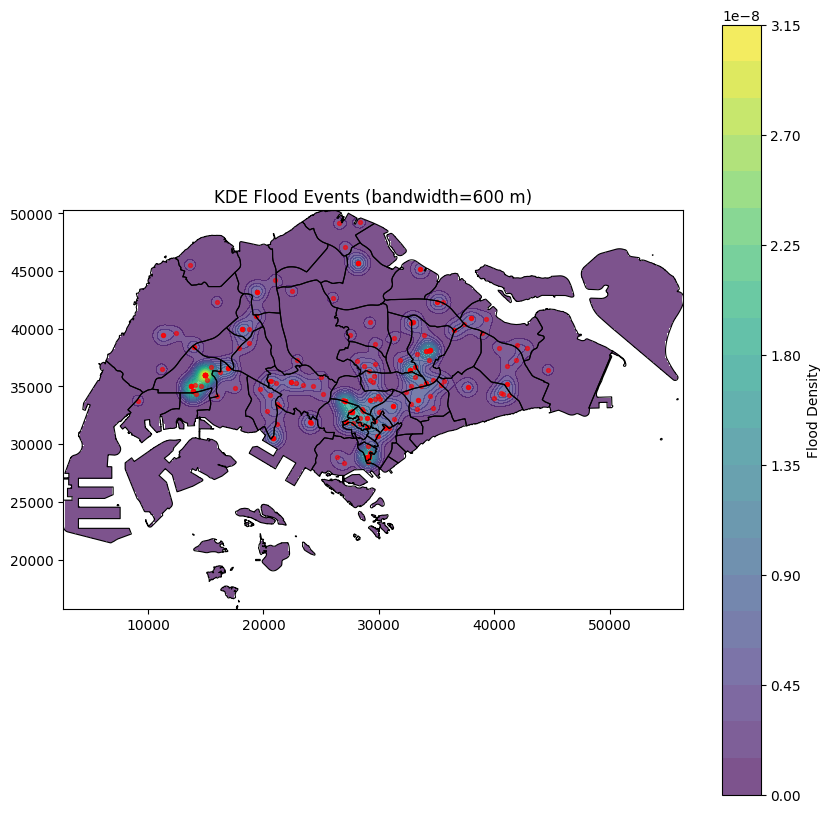

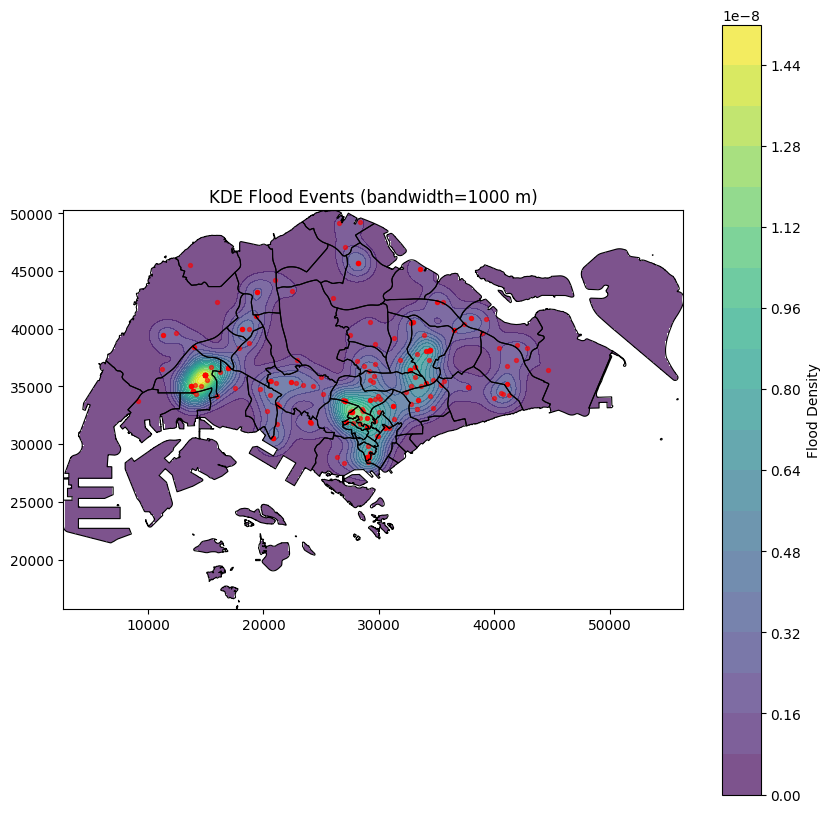

In [26]:
# ===============================================================
# 5. Bandwidth Comparison
# ===============================================================
for bw in [300, 600, 1000]:
    kde = KernelDensity(bandwidth=bw, kernel="gaussian").fit(coords)
    zz = np.exp(kde.score_samples(grid_coords)).reshape(xx.shape)
    mask = np.array([study_area.contains(Point(x, y)) for x, y in grid_coords]).reshape(xx.shape)
    zz_masked = np.where(mask, zz, np.nan)

    fig, ax = plt.subplots(figsize=(10,10))
    planning_area.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8)
    c = ax.contourf(xx, yy, zz_masked, cmap="viridis", levels=20, alpha=0.7)
    gdf.plot(ax=ax, color="red", markersize=8, alpha=0.6)
    fig.colorbar(c, ax=ax, label="Flood Density")
    plt.title(f"KDE Flood Events (bandwidth={bw} m)")
    plt.show()


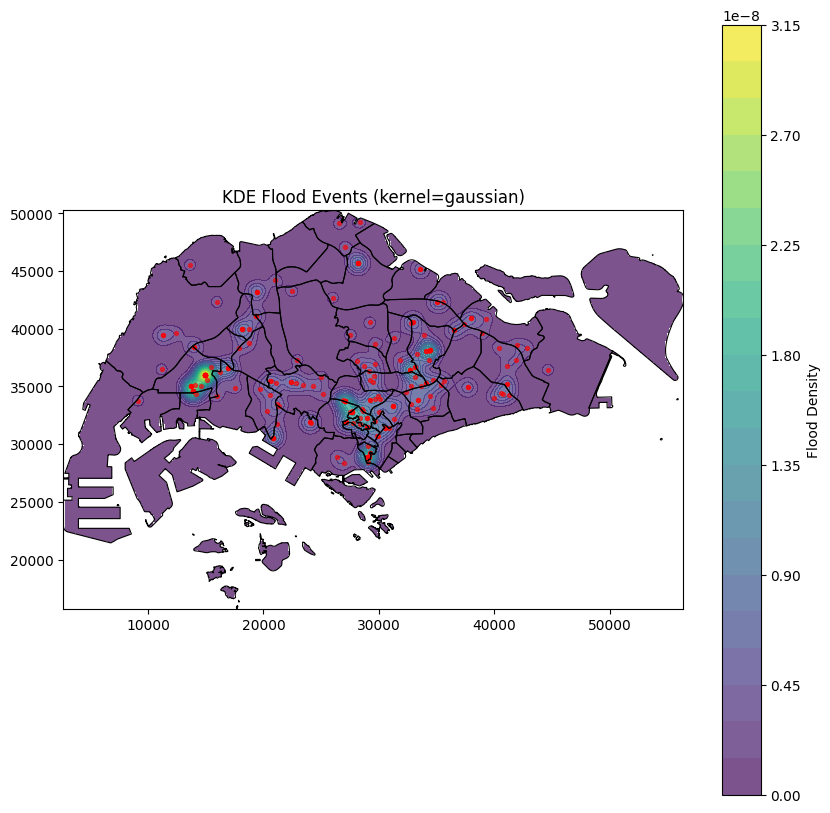

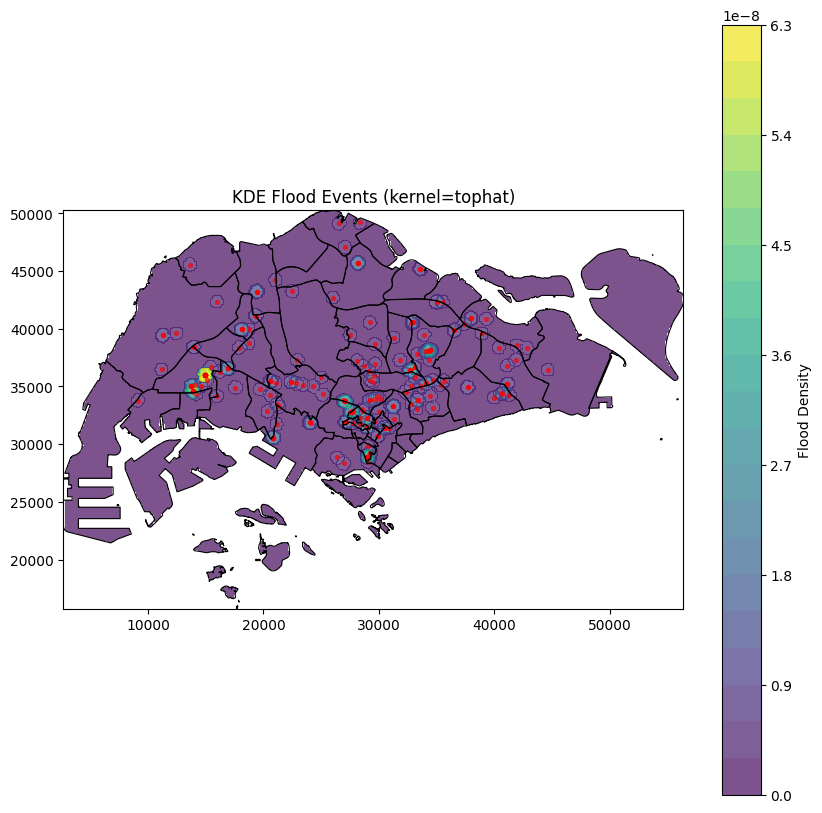

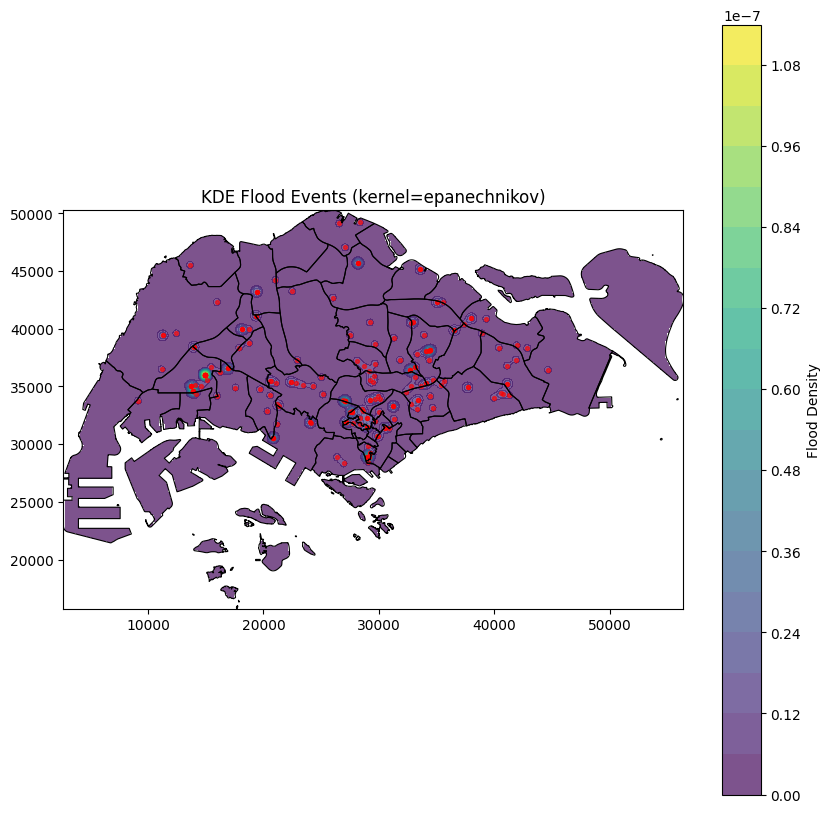

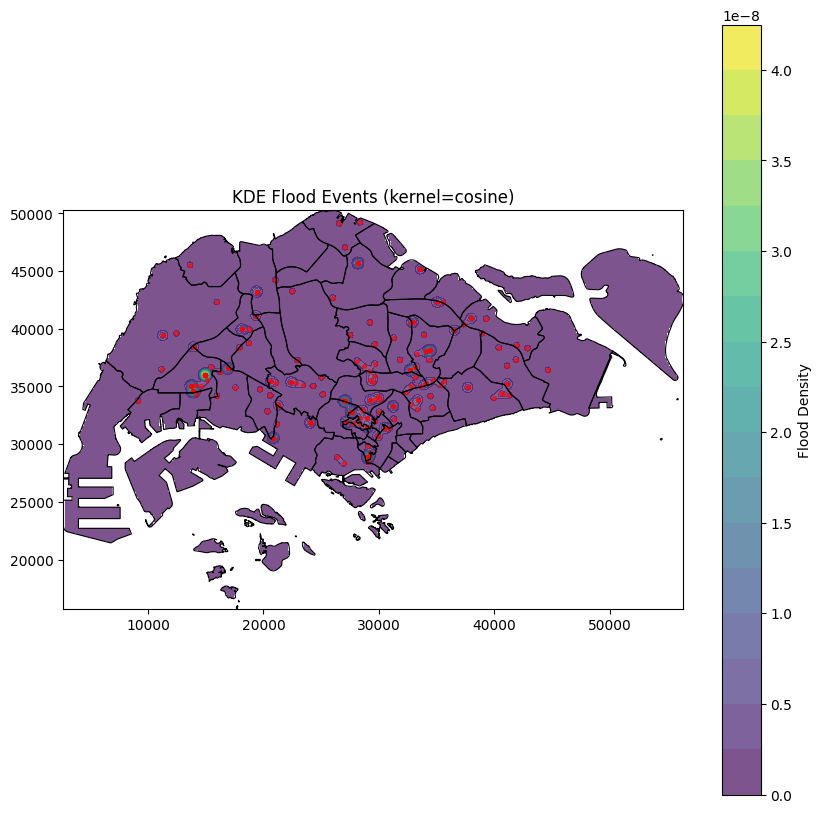

In [27]:
# ===============================================================
# 6. Kernel Comparison
# ===============================================================
for kernel in ["gaussian", "tophat", "epanechnikov", "cosine"]:
    kde = KernelDensity(bandwidth=600, kernel=kernel).fit(coords)
    zz = np.exp(kde.score_samples(grid_coords)).reshape(xx.shape)
    mask = np.array([study_area.contains(Point(x, y)) for x, y in grid_coords]).reshape(xx.shape)
    zz_masked = np.where(mask, zz, np.nan)

    fig, ax = plt.subplots(figsize=(10,10))
    planning_area.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8)
    c = ax.contourf(xx, yy, zz_masked, cmap="viridis", levels=20, alpha=0.7)
    gdf.plot(ax=ax, color="red", markersize=8, alpha=0.6)
    fig.colorbar(c, ax=ax, label="Flood Density")
    plt.title(f"KDE Flood Events (kernel={kernel})")
    plt.show()

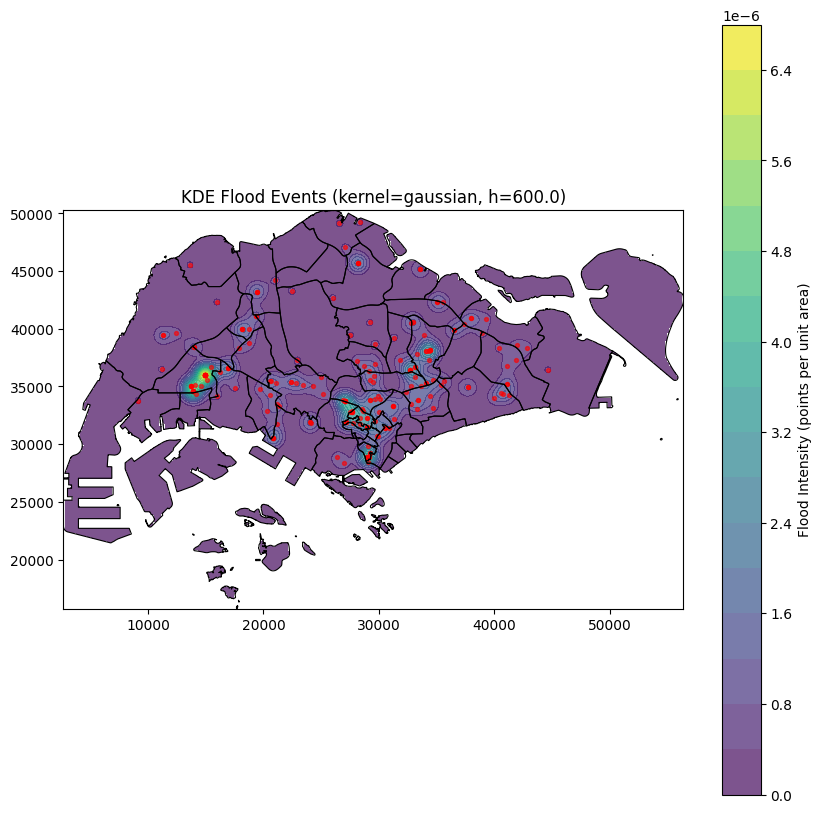

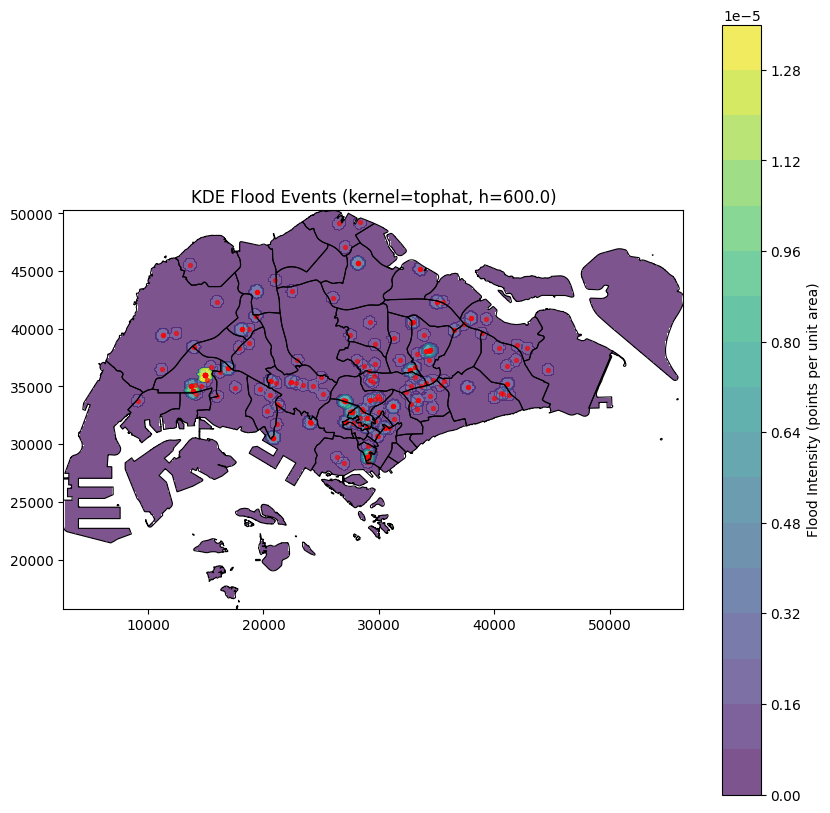

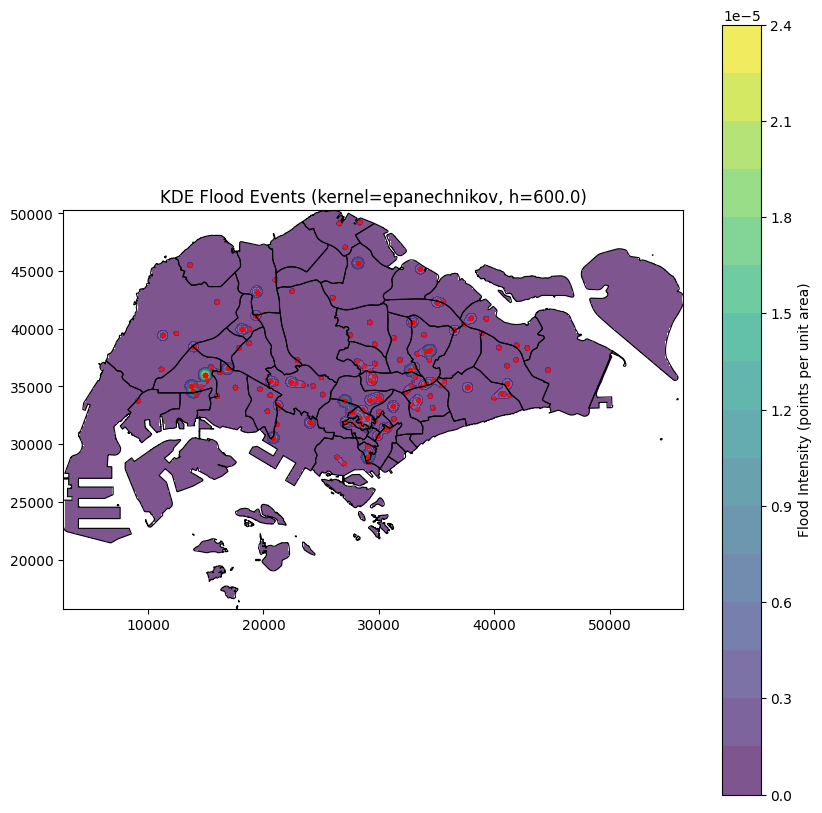

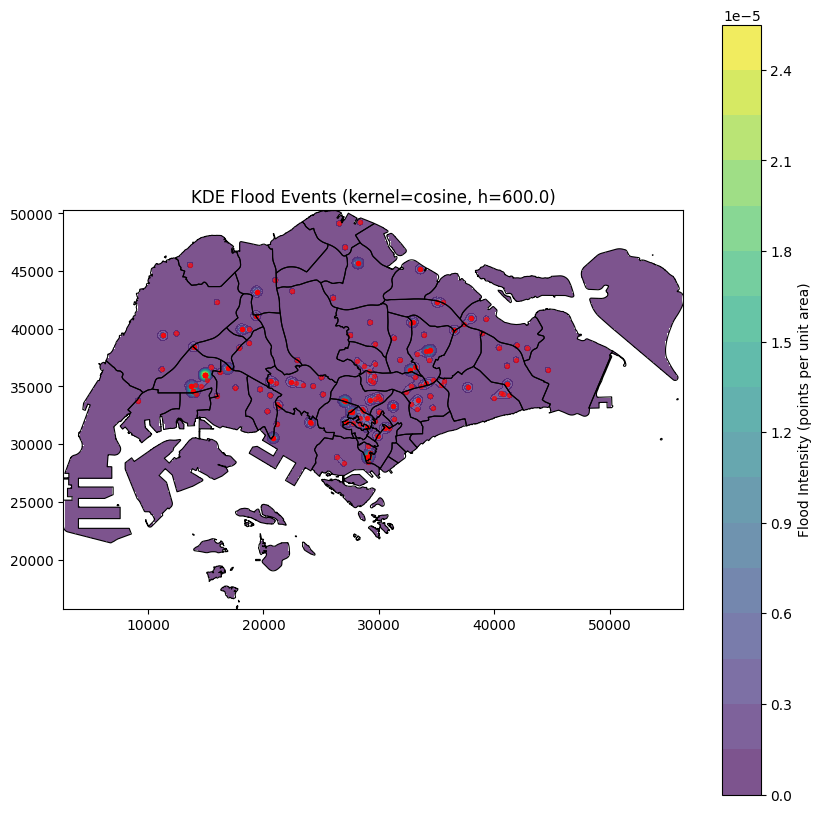

In [28]:
# ===============================================================
# 7. Standardised Distances
# ===============================================================


# ---- Standardised radial kernels (2D) ----
def kernel_2d_radial(u, kernel):
    """Return k(u) for radial kernel profile (u >= 0).
       These are normalised for 2D: 2π∫ u k(u) du = 1.
    """
    if kernel == "gaussian":
        return (1.0 / (2.0 * math.pi)) * np.exp(-0.5 * u**2)
    elif kernel == "tophat":
        return (1.0 / math.pi) * (u <= 1.0).astype(float)
    elif kernel == "epanechnikov":
        return (2.0 / math.pi) * np.maximum(0.0, 1.0 - u**2)
    elif kernel == "cosine":
        A = 0.6879845984710272  # precomputed for 2D normalisation
        return A * np.cos(np.pi * u / 2.0) * (u <= 1.0).astype(float)
    else:
        raise ValueError("Unknown kernel")

# ---- KDE function ----
def kde_manual_2d(coords, grid_coords, h, kernel="gaussian"):
    coords = np.asarray(coords)
    grid = np.asarray(grid_coords)
    n = coords.shape[0]

    # Pairwise distances (M, N)
    diffs = grid[:, None, :] - coords[None, :, :]
    r = np.sqrt(np.sum(diffs**2, axis=2))
    u = r / h

    # Radial kernel
    k_vals = kernel_2d_radial(u, kernel=kernel)

    # Factor 1/h^2 (for 2D scaling)
    contributions = (1.0 / (h**2)) * k_vals

    # Probability density (integrates to 1 across whole plane)
    zz_prob = np.sum(contributions, axis=1) / n

    # Intensity (points per unit area, integrates to n)
    zz_intensity = zz_prob * n

    return zz_prob, zz_intensity

# ---- Your loop (replace sklearn KDE) ----
h = 600.0
n = coords.shape[0]

dx = xx[0,1] - xx[0,0]   # grid spacing in X
dy = yy[1,0] - yy[0,0]   # grid spacing in Y
cell_area = dx * dy

for kernel in ["gaussian", "tophat", "epanechnikov", "cosine"]:
    # Run KDE
    zz_prob, zz_intensity = kde_manual_2d(coords, grid_coords, h, kernel=kernel)

    # Reshape to grid
    zz_prob_r = zz_prob.reshape(xx.shape)
    zz_int_r = zz_intensity.reshape(xx.shape)

    # Mask outside study area
    mask = np.array([study_area.contains(Point(x, y)) for x, y in grid_coords]).reshape(xx.shape)
    zz_prob_masked = np.where(mask, zz_prob_r, np.nan)
    zz_int_masked = np.where(mask, zz_int_r, np.nan)

    # Optional: renormalise probability inside mask
    total_mass_inside = np.nansum(zz_prob_masked * cell_area)
    if total_mass_inside > 0:
        zz_prob_norm_inside = zz_prob_masked / total_mass_inside
    else:
        zz_prob_norm_inside = zz_prob_masked

    # Plot intensity surface (common in spatial analysis)
    fig, ax = plt.subplots(figsize=(10,10))
    planning_area.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8)
    c = ax.contourf(xx, yy, zz_int_masked, cmap="viridis", levels=20, alpha=0.7)
    gdf.plot(ax=ax, color="red", markersize=8, alpha=0.6)
    fig.colorbar(c, ax=ax, label="Flood Intensity (points per unit area)")
    plt.title(f"KDE Flood Events (kernel={kernel}, h={h})")
    plt.show()


## Second point analysis


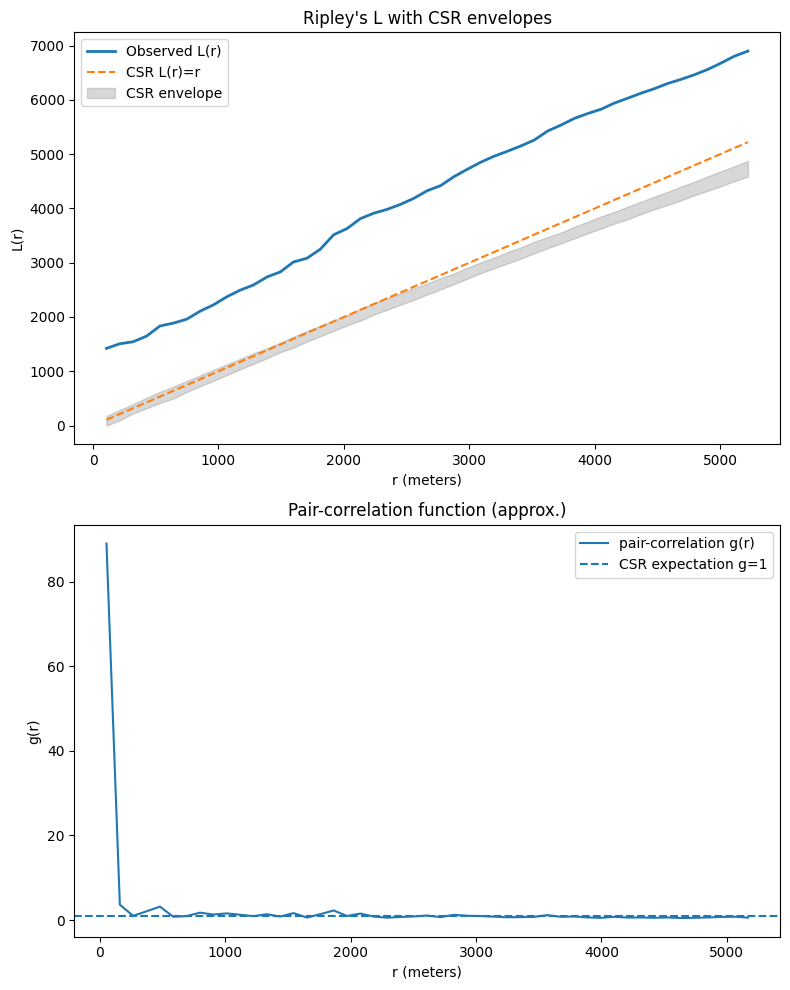

In [42]:
# if your geometry column is not points, make sure to extract points
if gdf.geometry.geom_type.unique().tolist() != ['Point']:
    raise ValueError("GeoDataFrame must contain Points")

# extract coordinates as numpy array (x,y)
coords = np.vstack([ (pt.x, pt.y) for pt in gdf.geometry ])

# compute study window bounding rectangle and area
xmin, ymin, xmax, ymax = gdf.total_bounds
area = (xmax - xmin) * (ymax - ymin)

# --------- 2. Create PointPattern and compute Ripley's K / L ----------
pp = PointPattern(coords)

# choose range of distances (r)
maxr = min(xmax - xmin, ymax - ymin) / 4.0  # rule-of-thumb upper limit
r_vals = np.linspace(0.0, maxr, 50)[1:]  # avoid 0

r_out, K_vals = k(coords, support=r_vals, edge_correction=None)

L_vals = np.sqrt(K_vals / np.pi)
L_theo = r_out

# --------- 3. Monte Carlo CSR envelopes using k_test ----------

bbox_poly = Polygon([
    (xmin, ymin), (xmax, ymin),
    (xmax, ymax), (xmin, ymax)
])

kt = k_test(
    coords,
    support=r_vals,
    hull=bbox_poly,           # polygon window, not tuple
    edge_correction=None,
    keep_simulations=True,
    n_simulations=199
)

K_obs = kt.statistic
sims = kt.simulations
K_lower = np.nanpercentile(sims, 2.5, axis=0)
K_upper = np.nanpercentile(sims, 97.5, axis=0)

L_obs  = np.sqrt(K_obs   / np.pi)
L_low  = np.sqrt(K_lower / np.pi)
L_high = np.sqrt(K_upper / np.pi)

# --------- 4. Pair-correlation function (approx) ----------
# pair-correlation g(r) approx from histogram of pairwise distances
dists = pdist(coords)  # all pairwise distances (1D)
# histogram
bin_edges = np.linspace(0.0, maxr, 50)
hist, edges = np.histogram(dists, bins=bin_edges)
bin_centers = 0.5 * (edges[:-1] + edges[1:])
# normalization for pair-correlation:
n = len(coords)
lambda_hat = n / area
# ring areas: area of annulus ~ pi*(r2^2 - r1^2)
ring_areas = np.pi * (edges[1:]**2 - edges[:-1]**2)
# expected number of pairs per ring under CSR: lambda_hat * ring_area * n
# But each pair counted once in pdist, so normalize accordingly.
g_r = hist / ( (n * lambda_hat) * ring_areas )

# --------- 5. Plot results ----------
fig, axs = plt.subplots(2,1, figsize=(8,10))

# Ripley L with envelopes
axs[0].plot(r_vals, L_obs, label="Observed L(r)", lw=2)
axs[0].plot(r_vals, L_theo, '--', label="CSR L(r)=r")
axs[0].fill_between(r_vals, L_low, L_high, color='gray', alpha=0.3, label='CSR envelope')
axs[0].set_xlabel('r (meters)')
axs[0].set_ylabel('L(r)')
axs[0].legend()
axs[0].set_title("Ripley's L with CSR envelopes")

# Pair-correlation plot
axs[1].plot(bin_centers, g_r, label='pair-correlation g(r)')
axs[1].axhline(1.0, linestyle='--', label='CSR expectation g=1')
axs[1].set_xlabel('r (meters)')
axs[1].set_ylabel('g(r)')
axs[1].legend()
axs[1].set_title('Pair-correlation function (approx.)')

plt.tight_layout()
plt.show()

# --------- 6. K-cross / marked patterns (brief notes) -----------
# If your points have a mark (type/category), you can split coords by mark
# and compute cross-K using either:
# - the 'explode' functionality in pointpats.PointPattern
# - or compute pairwise distances only between points of type A and type B
# Example hint (not full code here):
# types = gdf['type_column'].values
# coords_A = coords[types == 'A']
# coords_B = coords[types == 'B']
# then compute cross-K via pair counting restricted to cross pairs and normalize.


# Insights/conclusions from analysis above:
### Ripley's L shows that at nearly all spatial scales, points are clustered more frequently than expected by chance --> strong clustering behaviour at short distances
### The pair-correlation function g(r) also indicates significant clustering, with values greater than 1 at small distances --> significant clustering at discances less than ~500m
### This coulg indicate the following: (1) clustering of flood events could be a result of geographical factors (e.g. lower-lying areas, proximity to water bodies or drainage stystems that might overflow) (2) infrastructure issues (e.g. poor drainage systems in the area, insufficient flood mitigation measures) or (3) climate patterns (e.g. certain areas more prone to heavy rainfall) --> this last one is less likely as Singapore generally has a uniform climate across its small area